# **Project 1 - Sales Analysis - Visualisations

## Objectives

- Read data from combined csv files created from ETL processes
- Show plots to attempt to answer hypothesis


## Inputs

CSV files used:

Sales_Combined_DataSet.csv


Note: original files are stored in Data/OriginalFiles


## Outputs

CSV file created from ETL etc stored in Data:

Sales_Combined.csv



## Additional Comments

- Using as many of the plot libraries as possible but discovered some where not capable of showing the data in either the format I needed.

Needed to install:

pip install nbformat

For plotly visualisations to work


- Isolated the visualisations into a seperate notebook to keep the file size as low as possible.


## Initalise Working Environment

In [35]:
#import libraries
import os
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

#added by me for visualisation fine tuning
from matplotlib.ticker import MultipleLocator

#added by me for plotly.express visualisation issue
import nbformat 


# Section 1 - Initalisation

## Intitialise All Variables To Be Used In Global Stack 

In [36]:
#DataFrame vars for visualisation
dfSales_Combined_DataSet = None
#just in case need to add more Feature Engineering
dfSales_Combined_DataSet_Work = None

#stores current directory
strCurrentDir = ""

#constant for project directory
CNST_STR_PROJECT_DIR = "Project1-SalesAnalysis"

#file path constant
CNST_STR_SALESCOMBINEDFILEPATH = "/Data/VisualisationDataSet/Sales_Combined_DataSet.csv"

#other vars
lstStoreRanges = []
lstLabels = []
objStore = None
intYear = 0


## Set Current Directory To Base Project Directory

In [37]:
#get project directory - default is jupyter notebook sub folder as that is where this file is located!
#so move back one to the project root path
# Source - https://stackoverflow.com/a/17726833
# Posted by chimpsarehungry
# Retrieved 2026-07-05, License - CC BY-SA 3.0

#get current folder
strCurrentDir = os.getcwd()

#is the last part of the path the project directory?
if not strCurrentDir.endswith(CNST_STR_PROJECT_DIR):
   #get current working directory and move back one to the project root path
   strCurrentDir =  os.path.normpath(os.getcwd() + os.sep + os.pardir)
   os.chdir(os.path.dirname(strCurrentDir))
   #change directory
   os.chdir(strCurrentDir)

#confirm current directory is project directory
print(f"Current Directory: \n {os.getcwd()}")

Current Directory: 
 /Users/rogerwilliams/Projects/Python/CourseProjects/Project1-SalesAnalysis


# Section 1 - Read Data From CSV File

- Read csv file

## Read csv File Into Variable For Processing and Copy Into dfSales_Combined_DataSet_Work

In [38]:
#read csv files into DataFrames
dfSales_Combined_DataSet = pd.read_csv(strCurrentDir + CNST_STR_SALESCOMBINEDFILEPATH)

#copy DataFrame
dfSales_Combined_DataSet_Work = dfSales_Combined_DataSet.copy()

## Transform Date Column To Datetime Format

In [39]:
#transform Date to datetime
dfSales_Combined_DataSet_Work["Date"] = pd.to_datetime(dfSales_Combined_DataSet_Work["Date"], format="%d/%m/%Y")

#check schema
dfSales_Combined_DataSet_Work.dtypes

Unnamed: 0               int64
Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
Temperature            float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
Store_Size               int64
Store_Type               int64
YearMonth                int64
dtype: object

---

## Visualisations!

Each hypothesis will be visualised using:

- pandas
- matplotlib.pyplot
- plotly.express
- seaborn


## Hypothesis 1

Are sales increased if weather is hotter or colder in the last 12 months? 

## Visualisation library: pandas

<Axes: title={'center': 'Sales vs Temperature Over Last 12 Months'}, xlabel='Temperature', ylabel='Weekly_Sales'>

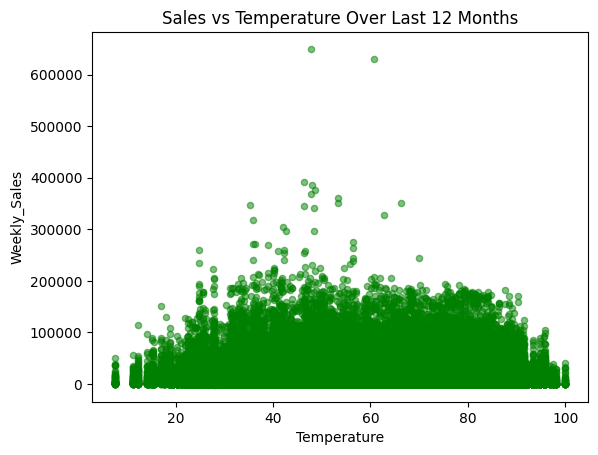

In [40]:
#pandas visualisation for hypothesis 1 - are sales increased if weather is hotter or colder in the last 12 months? 

#get 12 months from last date in DataFrame
dteStartDate = dfSales_Combined_DataSet_Work['Date'].max() - pd.DateOffset(months = 12)

#filter DataFrame for last 12 months
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'] >= dteStartDate]

#show plot
dfSales_Combined_DataSet_Filtered.plot(kind="scatter", x="Temperature", y="Weekly_Sales", 
                                       title="Sales vs Temperature Over Last 12 Months", color="green", alpha=0.5)


## Observations

Looks decent, certainly answers the hypothesis

## Visualisation library: matplotlib.pyplot

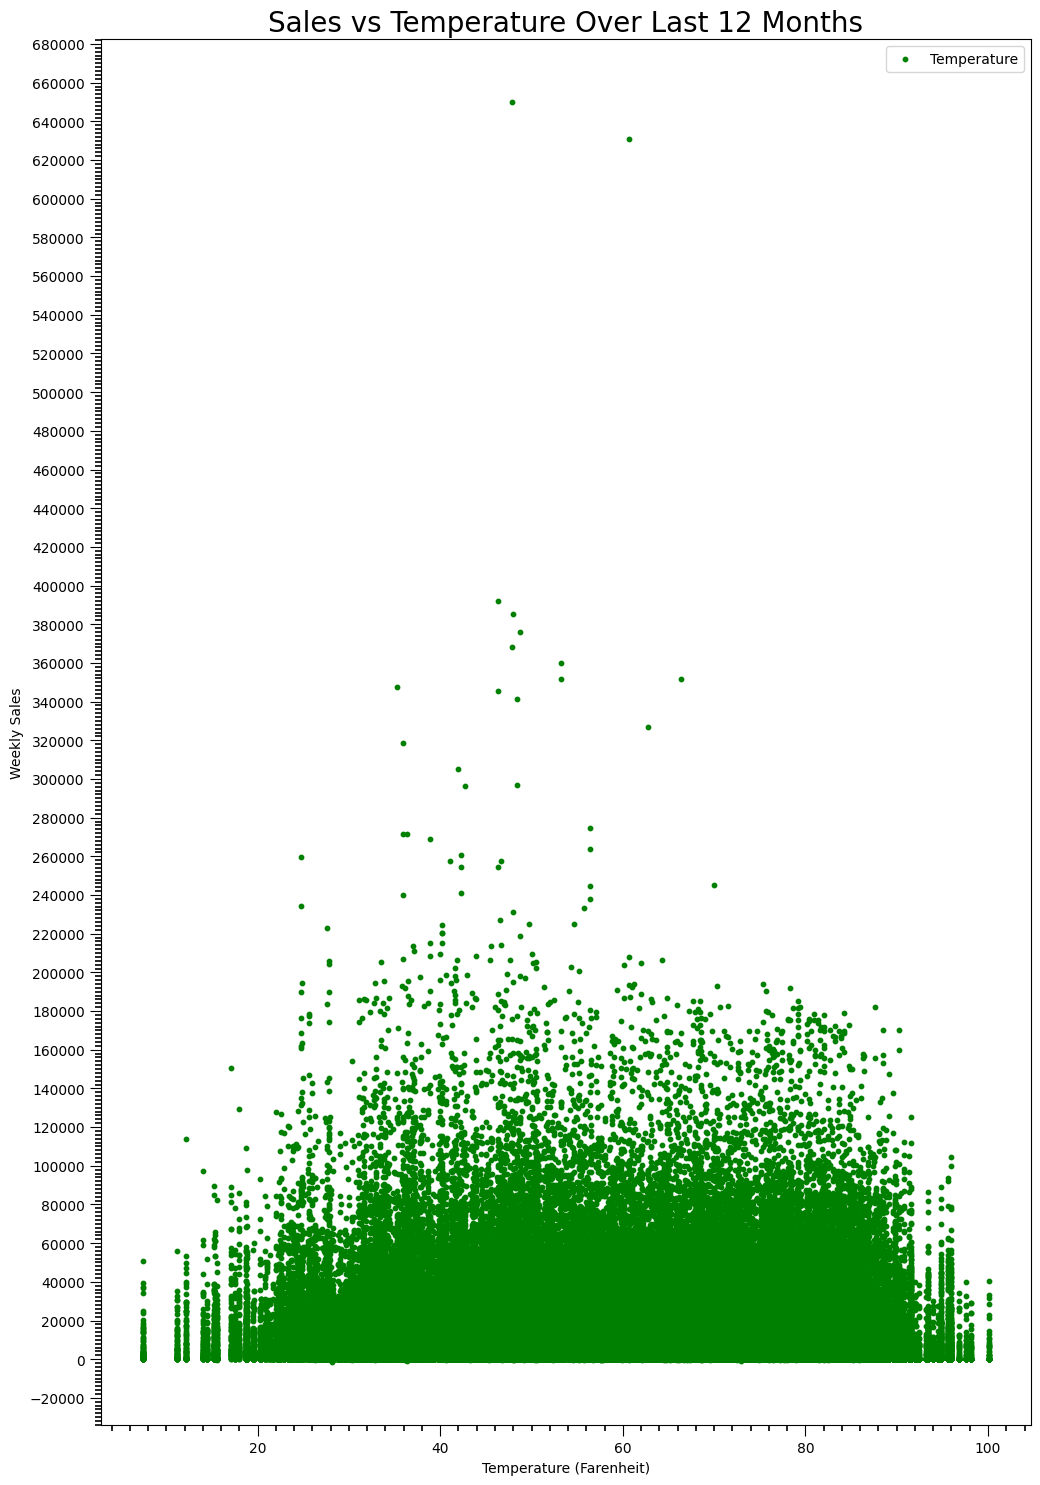

In [41]:
#matplotlib visualisation for hypothesis 1 - are sales increased if weather is hotter or colder in the last 12 months?  

#used chatGPT code to get "ticks" between axis values
#however due to a lack of knowledge am running the plot first then deciding what the
#ticks values are -DOH!

#get year from last date in DataFrame
intYear = dfSales_Combined_DataSet_Work['Date'].dt.year.max() -1

#filter DataFrame for last 12 months
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'] >= dteStartDate]

#set plot size
fig, ax = plt.subplots(figsize=(12, 18))

#show plot
ax.scatter(
    dfSales_Combined_DataSet_Filtered["Temperature"],
    dfSales_Combined_DataSet_Filtered["Weekly_Sales"],
    alpha=1,
    label="Temperature",
    color="green",
    s=10
)


#this code came from chatGPT and has been HEAVILY modified
# Major ticks every 20 units
ax.xaxis.set_major_locator(MultipleLocator(20))

# Minor ticks every 2 units
ax.xaxis.set_minor_locator(MultipleLocator(2))

#my added code
# Major ticks every 100000 units
ax.yaxis.set_major_locator(MultipleLocator(20000))

# Minor ticks every 2000 units
ax.yaxis.set_minor_locator(MultipleLocator(2000))

 #set tick params for x axis
ax.tick_params(axis='y', which='minor', length=4, width=1.2)
ax.tick_params(axis='y', which='major', length=8, width=0.8)
#end of my added code


# #set tick params for y axis
ax.tick_params(axis='x', which='minor', length=4, width=1.2)
ax.tick_params(axis='x', which='major', length=8, width=0.8)
#end of chatGPT code

#set title and labels
ax.set_title("Sales vs Temperature Over Last 12 Months", fontsize=20)
ax.set_xlabel("Temperature (Farenheit)")
ax.set_ylabel("Weekly Sales")
#position legend
ax.legend(loc="upper right")
#show plot!
plt.show()



## Observations

Due to the added "ticks" between each axis value needde to make the plot bigger to see the data points, but the plot looks good and answers the hypothesis.

Note: Is there a better way of doing this?

## Visualisation library: plotly.express

In [ ]:
#plotly visualisation for hypothesis 1 - are sales increased if weather is hotter or colder in the last 12 months? 
#Note: in order for the "ticks" to show on the axes Plotly needs to be version 5.8 or higher

#get year from last date in DataFrame
intYear = dfSales_Combined_DataSet_Work['Date'].dt.year.max() -1

#filter DataFrame for last 12 months
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'] >= dteStartDate]

#set plot size
fig = px.scatter(dfSales_Combined_DataSet_Filtered , x="Temperature", y="Weekly_Sales",
           title="Sales vs Temperature Over Last 12 Months", color="Temperature", opacity=0.5)

#code copied from chatGPT
fig.update_xaxes(
    ticks="outside",
    minor=dict(
        ticks="outside",
        ticklen=4,
        showgrid=False
    )
)

fig.update_yaxes(
    ticks="outside",
    minor=dict(
        ticks="outside",
        ticklen=4,
        showgrid=False
    )
)
#remove after testing
fig.update_xaxes(dtick=10)        # every 10 degrees
fig.update_yaxes(dtick=100000)    # every 100,000 sales
#end code copied from chatGPT

fig.show()

## Observations

Answers the hypothesis and is the best looking plot so far intially.  
However, seems to be missing some higher values (??) - need to investigate further.

## Visualisation library: SeaBorn

In [ ]:
#seaborn visualisation for hypothesis 1 - are sales increased if weather is hotter or colder in the last 12 months? 

#get year from last date in DataFrame
intYear = dfSales_Combined_DataSet_Work['Date'].dt.year.max() -1

#filter DataFrame for last 12 months
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'] >= dteStartDate]

#set plot size
fig = sns.scatterplot(data=dfSales_Combined_DataSet_Filtered, x="Temperature", y="Weekly_Sales", 
                color="green", alpha=0.5)

fig.set_title("Scatter Plot Of Temperature Vs Weekly Sales Over Last 12 Months", fontsize=16)

## Observations

Answers hypothesis not as good looking as the plotly version

## Visualisation library: Plotly

In [ ]:
#plotly visualisation for hypothesis 1 - are sales increased if weather is hotter or colder in the last 12 months? 

#used chatGPT code to get "ticks" between axis values
#however due to a lack of knowldege am running the plot first then deciding what the
#ticks values are -DOH!

#get year from last date in DataFrame
intYear = dfSales_Combined_DataSet_Work['Date'].dt.year.max() -1

#filter DataFrame for last 12 months
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'] >= dteStartDate]

#set plot size
fig = px.scatter(
    dfSales_Combined_DataSet_Filtered,
    x="Temperature",
    y="Weekly_Sales"
)

#set title and labels
fig.update_layout(
    title="Sales vs Temperature Over Last 12 Months",
    xaxis_title="Temperature (Farenheit)",
    yaxis_title="Weekly Sales"
)
#show plot!
fig.show()



## Observations

Answers the hypothesis.
However, seems to be missing some higher values (??) - need to investigate further.

## Conclusions - Hypothesis 1

When I looked at the raw data files this hypothesis came to mind, but as always when new to something knowing WHICH plot to use and IF the hypothesis is even feasible were the main issues.

Thought scatter plot best represents the data.

Fingers crossed I have chose wisely, as to me it shows what was required

## Hypothesis 2

Sales differences between holiday and non-holiday weeks per store over last 12 months

## Visualisation library: pandas

After many attempts discovered pandas on its own could not visualise the data the way I envisaged, and what it produced was hard to read and understand.
So have used matplotlib.pyplot to visualise the data instead so nothing more in this section

## Visualisation library: pandas/matplotlib.pyplot

In [ ]:
#pandas/matplotlib.pyplot visualisation for hypothesis 2 - Sales differences between holiday and non-holiday 
#weeks per store for last 12 months


#define list of store numbers as a set of ranges
#there is probably some clever way of doing this dynamically but I don't know it!
#so went "old skool" and simply looked at the last store number in the csv file: stores data-set.csv
#obviously if more stores are added this isn't a good solution!
lstStoreRanges = [
    range(1, 10),
    range(10, 20),
    range(20, 30),
    range(30, 40),
    range(40, 46)
]

#read through DataFrame see if store number is in range
#Note: this is probably a mute step but is a a god way of validating the result BEFORE
#      creating a plot

#get year from last date in DataFrame
intYear = dfSales_Combined_DataSet_Work['Date'].dt.year.max() -1

#filter DataFrame for last 12 months
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'] >= dteStartDate]

#set plot size

for intStores in lstStoreRanges:
    #add row to new DataFrame
    dfSales_Combined_DataSet_SubSet = dfSales_Combined_DataSet_Filtered[
        dfSales_Combined_DataSet_Filtered["Store"].isin(intStores)
    ]

    #set subplots defaults
    ax = dfSales_Combined_DataSet_SubSet.boxplot(
        column="Weekly_Sales",
        by=["Store", "IsHoliday"],
        figsize=(20, 6),
        #rotate to make easier to read
        rot=90,
        color = "blue"
    )

    #avoid any unwanted titles
    plt.suptitle("")
    #set plot main title
    plt.title(f"Sales Differences Between Holiday and Non Holiday Weeks Over Last 12 Months - Stores: {min(intStores)}-{max(intStores)}",
              fontsize=20)
    #set axis
    plt.xlabel("Store / Holiday Status")
    plt.ylabel("Weekly Sales")

    #clear labels list
    lstLabels = []
    
    #if current store number matches the store number in the main loop
    for intCurrentStore in intStores:
        #make sure value actually exists
        if intCurrentStore in dfSales_Combined_DataSet_SubSet["Store"].unique():
           #update labels with meaningful data 
           lstLabels.append(f"Store {intCurrentStore}\nNon-Holiday")
           lstLabels.append(f"Store {intCurrentStore}\nHoliday")

    #update plot with new labels
    ax.set_xticklabels(lstLabels)

    #plt.tight_layout()
    plt.show()

## Observations

Answers the hypothesis, still looking for a better plot to visualise the data, main issue is the sheer volumne of it in terms of store numbers.

## Visualisation library: Plotly

In [ ]:
#plotly visualisation for hypothesis 2 - Sales differences between holiday and non-holiday weeks per store
#for last 12 months

#create plot
fig = px.box(dfSales_Combined_DataSet,
    x="Store",
    y="Weekly_Sales",
    color="IsHoliday",
    title="Sales Differences Between Holiday and Non-Holiday Weeks Per Store Last 12 Momths",
    labels={
        "IsHoliday": "Holiday Status",
        "Weekly_Sales": "Total Weekly Sales"
    },
    #set plot size
    height=600,
    width=1050
)

fig.show()

## Observations

Answers the hypothesis, best looking plot so far!

## Visualisation library: SeaBorn

In [ ]:
#seaborn visualisation for hypothesis 2 - Sales differences between holiday and non-holiday weeks per store
#for last 12 months

#get year from last date in DataFrame
intYear = dfSales_Combined_DataSet_Work['Date'].dt.year.max() -1

#filter DataFrame for last 12 months
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'] >= dteStartDate]

#set size of plot
plt.figure(figsize=(28, 12))
#set plot type, DataFrame, x/y axis columns and hue for holiday status
sns.boxplot(data=dfSales_Combined_DataSet_Filtered, x="Store", y="Weekly_Sales", hue="IsHoliday", 
            width=0.8)
#set plot title
plt.title("Sales Differences Between Holiday and Non-Holiday Weeks Per Store Over Last 12 Months",fontsize=20)
#set axis labels
plt.xlabel("Store")
plt.ylabel("Total Weekly Sales")
#show plot
plt.show()



## Observations

Answers the hypothesis, not happy with the plot size compared to plotly, which so far is far superior in terms of look and readability..

Will see on the internet what the options for the plot type are...maybe subplots is the answer?

## Conclusions - Hypothesis 2

Great idea, looks great in plotly, not so good in the others. 

As will all visualisations I am using, not aiming for the graphically stunning plot with zooming widgets and dancing bears. Aiming to present the information as clearly and simply as possible.

Thought boxplot was best after trying lots of options some of which would not render!

(Yes, I am secretly plotting (pun intended) to find a use for a 3D plot!!)

## Hypothesis 3

What is most profitable store type over the last 12 months?

## Visualisation library: pandas/matplotlib.pyplot

In [ ]:
#pandas/matplotlib.pyplot visualisation for hypothesis 3: what is most profitable store type over the last 12 months?
#a question that has pondered the minds of great retail philosophers, can I answer it?

#get year from last date in DataFrame
intYear = dfSales_Combined_DataSet_Work['Date'].dt.year.max() -1

#filter DataFrame for last 12 months
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'] >= dteStartDate]

#filter data by doing simple grouby on store type and weekly sales
#reset the index so that the store type is a column and not an index
dfSales_Combined_DataSet_StoreType = dfSales_Combined_DataSet_Filtered.groupby("Store_Type")["Weekly_Sales"].sum().reset_index()

#create the plot
ax = dfSales_Combined_DataSet_StoreType.plot(
    kind="bar",
    x="Store_Type",
    y="Weekly_Sales",
    title="Most Profitable Store By Type Over Last 12 Months",
    legend=False,
    xlabel="Store Type",
    ylabel="Total Weekly Sales",
    #make sure x axis labels are not rotated
    rot=0
)

plt.show()

## Observations

Answers the hypothesis, just what I was looking for, clean, simple, direct.

Only issue is the mysterious: 1e9 in the top left corner(??)

## Visualisation library: Plotly.Express    

In [ ]:
#plotly visualisation for hypothesis 3 - What is most profitable store type over the last 12 months?

#create plot#get year from last date in DataFrame
intYear = dfSales_Combined_DataSet_Work['Date'].dt.year.max() -1

#filter DataFrame for last 12 months
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'] >= dteStartDate]

#filter data by doing simple grouby on store type and weekly sales
#reset the index so that the store type is a column and not an index
dfSales_Combined_DataSet_StoreType = dfSales_Combined_DataSet_Filtered.groupby("Store_Type")["Weekly_Sales"].sum().reset_index()

#splot chart
fig = px.bar(dfSales_Combined_DataSet_StoreType,
    x="Store_Type",
    y="Weekly_Sales",
    color="Weekly_Sales",
    title="Most Profitable Store By Type Over Last 12 Months",
    labels={
        "IsHoliday": "Holiday Status",
        "Weekly_Sales": "Total Weekly Sales"
    },
    #set plot size
    height=600,
    width=1050
)

#by default plotly will show 1B, 2B in the y axis so change it to something more understandable
fig.update_yaxes(
    tickprefix="£",
    tickformat=","
)
fig.show()

## Observations

Answers the hypothesis, just what I was looking for, clean, simple, direct as usual plotly rules!

## Visualisation library: SeaBorn

In [ ]:
#seaborn visualisation for hypothesis 3 What is most profitable store type over the last 12 months?

#create plot#get year from last date in DataFrame
intYear = dfSales_Combined_DataSet_Work['Date'].dt.year.max() -1

#filter DataFrame for last 12 months
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'] >= dteStartDate]

#set size of plot
plt.figure(figsize=(28, 12))
#set plot type, DataFrame, x/y axis columns and hue for holiday status
sns.barplot(data=dfSales_Combined_DataSet_Filtered, x="Store_Type", y="Weekly_Sales",
            width=0.8, palette="Blues_d", hue="Store_Type")
#set plot title
plt.title("Most Profitable Store By Type Over Last 12 Months",fontsize=30)
#set axis labels
plt.xlabel("Store Type")
plt.ylabel("Total Weekly Sales")
#show plot
plt.show()


## Observations

Answers the hypothesis, nice and simple, challenges the plotly version. Would prefer a gap between the title and the plot area. 

Will have snoop on the intenet if I have time..

## Conclusions - Hypothesis 3

Great idea, looks great in plotly and Seaborn, while may not be eactly "pushing the envelope" as far as data mainpulation, is still the type of clear direct information the client wants.

From this more complex plots could be created, drilling into departments profitability per store etc.

## Hypothesis 4

Does store size affect profitability? If so, how much over the last 12 months?

## Visualisation library: pandas/matplotlib.pyplot

In [ ]:
#pandas/matplotlib.pyplot visualisation for hypothesis 4: Does store size affect profitability? If so, how much?
#over the last 12 months?
#modified version of a previous plot (self plagarism) if have time will look at other plot types

#create the plot

#define list of store numbers as a set of ranges
#there is probably some clever way of doing this dynamically but I don't know it!
#so went "old skool" and simply looked at the last store number in the csv file: stores data-set.csv
#obviously if more stores are added this isn't a good solution!
lstStoreRanges = [
    range(1, 10),
    range(10, 20),
    range(20, 30),
    range(30, 40),
    range(40, 46)
]

#create plot#get year from last date in DataFrame
intYear = dfSales_Combined_DataSet_Work['Date'].dt.year.max() -1

#filter DataFrame for last 12 months
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'] >= dteStartDate]

#read through DataFrame see if store number is in range
#Note: this is probably a mute step but is a a god way of validating the result BEFORE
#      creating a plot

for intStores in lstStoreRanges:
    #add row to new DataFrame
    dfSales_Combined_DataSet_SubSet = dfSales_Combined_DataSet_Filtered [
       dfSales_Combined_DataSet_Filtered["Store"].isin(intStores)
   ]

    #set subplots defaults
    ax = dfSales_Combined_DataSet_SubSet.plot(kind="scatter",
        x="Store_Size",
        y="Weekly_Sales",
        figsize=(20, 10),
        #rotate to make easier to read
        rot=90,
        color = "blue"
    )
    
    # Major ticks every 100000 units
    ax.xaxis.set_major_locator(MultipleLocator(10000))

    # Minor ticks every 1000 units
    ax.xaxis.set_minor_locator(MultipleLocator(1000))

    #set tick params for x axis
    ax.tick_params(axis='x', which='minor', length=4, width=1.2)
    ax.tick_params(axis='x', which='major', length=8, width=0.8)

    # Major ticks every 100000 units
    ax.yaxis.set_major_locator(MultipleLocator(100000))

    # Minor ticks every 1000 units
    ax.yaxis.set_minor_locator(MultipleLocator(10000))

    #set tick params for x axis
    ax.tick_params(axis='y', which='minor', length=4, width=1.2)
    ax.tick_params(axis='y', which='major', length=8, width=0.8)
    
    #set plot main title
    plt.title(f"Most Profitable Store By Size Last 12 Months - Stores: {min(intStores)}-{max(intStores)}",
              fontsize=20)
    #set axis
    plt.xlabel("Store Size")
    plt.ylabel("Weekly Sales")

    plt.show()

## Observations

Answers the hypothesis, nice and simple, the subplots was a good idea I had. Originally I had it in one huge plot, and that as hard to read.

As I go through these hyopthesis I am learning more about creating effective plots.

## Visualisation library: Plotly.Express

In [ ]:
#plotly visualisation for hypothesis 4 - Does store size affect profitability? If so, how much?
#over the last 12 months?

#create the plot

#define list of store numbers as a set of ranges
#there is probably some clever way of doing this dynamically but I don't know it!
#so went "old skool" and simply looked at the last store number in the csv file: stores data-set.csv
#obviously if more stores are added this isn't a good solution!
lstStoreRanges = [
    range(1, 10),
    range(10, 20),
    range(20, 30),
    range(30, 40),
    range(40, 46)
]

#create plot#get year from last date in DataFrame
intYear = dfSales_Combined_DataSet_Work['Date'].dt.year.max() -1

#filter DataFrame for last 12 months
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'] >= dteStartDate]

#read through DataFrame see if store number is in range
#Note: this is probably a mute step but is a a god way of validating the result BEFORE
#      creating a plot

for intStores in lstStoreRanges:
    #add row to new DataFrame
    dfSales_Combined_DataSet_SubSet = dfSales_Combined_DataSet_Filtered [
       dfSales_Combined_DataSet_Filtered["Store"].isin(intStores)
   ]

    #set subplots defaults
    fig = dfSales_Combined_DataSet_SubSet.plot(kind="scatter",
        x="Store_Size",
        y="Weekly_Sales",
        figsize=(20, 10),
        #rotate to make easier to read
        rot=90,
        color = "blue",
        title=f"Most Profitable Store By Size Over Last 12 Months - Stores: {min(intStores)}-{max(intStores)}",
        xlabel="Store Size",
        ylabel="Weekly Sales"   
    )
    
    # Major ticks every 100000 units
    fig.xaxis.set_major_locator(MultipleLocator(10000))

    # Minor ticks every 1000 units
    fig.xaxis.set_minor_locator(MultipleLocator(1000))

    #set tick params for x axis
    fig.tick_params(axis='x', which='minor', length=4, width=1.2)
    fig.tick_params(axis='x', which='major', length=8, width=0.8)

    # Major ticks every 100000 units
    fig.yaxis.set_major_locator(MultipleLocator(100000))

    # Minor ticks every 1000 units
    fig.yaxis.set_minor_locator(MultipleLocator(10000))

    #set tick params for x axis
    fig.tick_params(axis='y', which='minor', length=4, width=1.2)
    fig.tick_params(axis='y', which='major', length=8, width=0.8)


## Observations

Answers the hypothesis, nice and simple, subplots saves it from being a jumbled mess.

For this plot plotly isn't the outright winner, which is a surprise.

## Visualisation library: SeaBorn

In [ ]:
#SeaBorn visualisation for hypothesis 4 - Does store size affect profitability? If so, how much?
#over the last 12 months?

#create the plot

#define list of store numbers as a set of ranges
#there is probably some clever way of doing this dynamically but I don't know it!
#so went "old skool" and simply looked at the last store number in the csv file: stores data-set.csv
#obviously if more stores are added this isn't a good solution!
lstStoreRanges = [
    range(1, 10),
    range(10, 20),
    range(20, 30),
    range(30, 40),
    range(40, 46)
]

#create plot#get year from last date in DataFrame
intYear = dfSales_Combined_DataSet_Work['Date'].dt.year.max() -1

#filter DataFrame for last 12 months
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'] >= dteStartDate]

#read through DataFrame see if store number is in range
#Note: this is probably a mute step but is a a god way of validating the result BEFORE
#      creating a plot

for intStores in lstStoreRanges:
    #add row to new DataFrame
    dfSales_Combined_DataSet_SubSet = dfSales_Combined_DataSet_Filtered [
       dfSales_Combined_DataSet_Filtered["Store"].isin(intStores)
   ]

    plt.subplots(figsize=(20, 10))
  
    #set subplots defaults
    sns.barplot(data=dfSales_Combined_DataSet_SubSet, x="Store_Size", y="Weekly_Sales",
                hue="Store_Size")

    #set tick params for x axis
    plt.tick_params(axis='x', which='minor', length=4, width=1.2)
    plt.tick_params(axis='x', which='major', length=8, width=0.8)

      
    #set title
    plt.title(f"Most Profitable Store By Size Over Last 12 Months - Stores: {min(intStores)}-{max(intStores)}",
              fontsize=20)
    plt.show()


## Observations

Answers the hypothesis, nice and simple, best looker so far.


## Conclusions - Hypothesis 4

Another piece of the puzzle, and as I go through these hypothesis I am learning more about plots to show data from large datasets.

Will review the plot choices if I have time, but for now I am happy with the results.

## Hypothesis 5

Weekly Sales by Store and Department Last 12 Months

## Visualisation library: Plotly.Express

In [ ]:
#

# Aggregate data
sunburst_data = (
    dfSales_Combined_DataSet_Work
    .groupby(["Store_Type", "Store", "Dept"], as_index=False)
    ["Weekly_Sales"]
    .sum()
)

# Remove negative and zero sales
sunburst_data = sunburst_data[
    sunburst_data["Weekly_Sales"] > 0
]

# Convert hierarchy columns to strings
sunburst_data["Store_Type"] = sunburst_data["Store_Type"].astype(str)
sunburst_data["Store"] = sunburst_data["Store"].astype(str)
sunburst_data["Dept"] = sunburst_data["Dept"].astype(str)


fig = px.sunburst(
    sunburst_data,
    path=["Store_Type", "Store", "Dept"],
    values="Weekly_Sales",
    custom_data=["Store_Type", "Store", "Dept"],
    title="Weekly Sales by Store Type → Store → Department"
)

fig.update_traces(
    hovertemplate=
        "<b>Store Type:</b> %{customdata[0]}<br>" +
        "<b>Store Number:</b> %{customdata[1]}<br>" +
        "<b>Department:</b> %{customdata[2]}<br>" +
        "<b>Total Weekly Sales:</b> £%{value:,.0f}" +
        "<extra></extra>"
)


fig.update_layout(
    width=1000,
    height=900
)

fig.show()

KeyError: 'Type'

In [ ]:


# Aggregate data
sunburst_data = (
    dfSales_Combined_DataSet_Work
    .groupby(["Store_Type", "Store", "Dept"], as_index=False)
    ["Weekly_Sales"]
    .sum()
)

# Remove negative and zero sales
sunburst_data = sunburst_data[
    sunburst_data["Weekly_Sales"] > 0
]

# Convert hierarchy columns to strings
sunburst_data["Store_Type"] = sunburst_data["Store_Type"].astype(str)
sunburst_data["Store"] = sunburst_data["Store"].astype(str)
sunburst_data["Dept"] = sunburst_data["Dept"].astype(str)


fig = px.sunburst(
    sunburst_data,
    path=["Store_Type", "Store", "Dept"],
    values="Weekly_Sales",
    custom_data=["Store_Type", "Store", "Dept"],
    title="Weekly Sales by Store Type → Store → Department"
)

fig.update_traces(
    hovertemplate=
        "<b>Store Type:</b> %{customdata[0]}<br>" +
        "<b>Store Number:</b> %{customdata[1]}<br>" +
        "<b>Department:</b> %{customdata[2]}<br>" +
        "<b>Total Weekly Sales:</b> £%{value:,.0f}" +
        "<extra></extra>"
)


fig.update_layout(
    width=1000,
    height=900
)

fig.show()

## Conclusions - Hypothesis 5


## Hypothesis 6 

Impact of markdowns on sales during holiday periods in the last 12 months by store

## Visualisation library: Plotly.Express

In [ ]:
#Plotly.Express visualisation for hypothesis 7: Impact of markdowns on sales during holiday periods 
#in the last 12 months by store

markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

#make copy of DataFrame
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work.copy()

#filter for JUST holidays
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Filtered[dfSales_Combined_DataSet_Filtered['IsHoliday'] == True]

#make sure date formatted correctly
dfSales_Combined_DataSet_Filtered['Date'] = pd.to_datetime(
    dfSales_Combined_DataSet_Filtered['Date'],
    dayfirst=True,
    errors='coerce'
)
#get latest date in DataFrame
latest = dfSales_Combined_DataSet_Filtered['Date'].max()
#filter DataFrame for last 12 months from above value
df12 = dfSales_Combined_DataSet_Filtered[dfSales_Combined_DataSet_Filtered['Date'] >= latest - pd.DateOffset(months=12)].copy()

# Aggregate
summary = (
    df12.groupby('Store')[['Weekly_Sales'] + markdown_cols]
    .sum()
    .reset_index()
)

# Convert markdown columns into rows
long = summary.melt(
    id_vars=['Store', 'Weekly_Sales'],
    value_vars=markdown_cols,
    var_name='Markdown Type',
    value_name='Markdown Value'
)

fig = px.sunburst(
    long,
    path=['Store', 'Markdown Type'],
    values='Markdown Value',
    color='Weekly_Sales',
    color_continuous_scale='Viridis',
    custom_data=['Weekly_Sales'],
    title="Impact Of Markdowns On Sales By Store During Holiday Periods In The Last 12 Months By Store"
)

fig.update_traces(
    hovertemplate=
        "<b>Store:</b> %{parent}<br>" +
        "<b>Markdown Type:</b> %{label}<br>" +
        "<b>Markdown Value:</b> $%{value:,.2f}<br>" +
        "<b>Weekly Sales:</b> $%{customdata[0]:,.2f}" +
        "<extra></extra>"
)

fig.show()



## Conclusions - Hypothesis 6

## Hypothesis 7



## Conclusions - Hypothesis 7



## Global Conclusions

Not completely happy with the visualisation, lack of knowledge/experience about best types of plots to use and best ways to process large datasets I think did impede me a little.

As I had many great visualisation ideas but no idea how to manifest some of them, I had to settle for what I could do with the knowledge I had at the time. (boo!)

Could have leaned heavily on Generative AI, but I think that defeats the point of learning! Prefer to use such tools as a last resort.

Practice makes perfect, and with what I have learnt so far I can only progress and me condifdent in my choices.

In essence these hypothesis are the starting point. They will create conversations amongst management which will lead to deeper analysis requests. 
